# Convolutional Neural Network - *Fruits-360* dataset

*Fruits-360* is a database containing images of fruits, vegetables, nuts, and seeds. (Mihai Oltean, Fruits-360 dataset, 2017-)

## Dataset & Preprocessing

This section describes the dataset used for the CNN-based image classification task, its original structure, and the preprocessing decisions adopted before training the models.

### Dataset Overview

- **Dataset:** *Fruits-360*
- **Problem Type:** Multi-class image classification
- **Input:** RGB fruit pictures
- **Output:** Predicted class label
- **Images Format:** JPG
- **Number of classes:** 142
- **Dataset split:** Original split preserved
    - **Training:** approximately 50%
    - **Validation:** approximately 25%
    - **Test:** approximately 25%

The Fruits-360 dataset is already organized into separate Training, Validation, and Test directories. Each directory contains one subfolder per class, where the folder name represents the corresponding label. Since the dataset already provides a predefined split, this original organization was preserved throughout the notebook. We do this in a way to avoid introducing accidental data leakage. 

Although the assignment refers specifically to fruit category classification, the selected version of Fruits-360 also includes other visually similar food categories, such as vegetables, nuts, and seeds. For this reason, the task was treated as a general multi-class object classification problem using all available classes instead of manually filtering the dataset.

### Image Size Strategy

The dataset provides images in different resolutions. In this notebook, two image-size strategies are used depending on the type of model being trained.

For the custom CNN architecture, we reduce the image size to `100x100` for faster training and to make it easier to perform multiple experiments with different architectural configurations such as convolutional filters, strides, padding, pooling layers, dropout, and data augmentation.

For the pretrained models, such as ResNet50 and MobileNetV2, larger image resolutions are used when appropriate.

This difference in input resolution will be considered when comparing the custom CNN with pretrained networks. The models are not being compared under exactly the same input conditions, because the `100x100` version contains less visual information than the original or resized larger images.

### Preprocessing Pipeline

The preprocessing pipeline follows these main steps:

1. **Loading images from the original directory structure** \
Images are loaded directly from the Training, Validation, and Test folders while preserving the class-folder structure.

2. **Resizing images according to the model type** \
Custom CNN models use `100x100` inputs, while pretrained models use the input size required or recommended by the selected architecture.

3. **Converting images to RGB format** \
All images are treated as RGB images to maintain a consistent three-channel input shape.

4. **Normalizing pixel values** \
Pixel values are scaled from the original `[0, 255]` range to a normalized range `[0, 1]`, for more stability.

5. **Encoding class labels** \
Class labels are inferred from the folder names and converted into categorical labels suitable for multi-class classification.

6. **Preserving validation and test independence** \
The validation set is used for monitoring training performance and tuning model choices, while the test set is kept separate and used only for final evaluation.

| Experiment  | Changes                    | Objective                            |
| ----------- | ---------------------------- | ----------------------------------- |
| E1          | Baseline CNN                 | Initial Model                     |



In [29]:
import os
from pathlib import Path

from PIL import Image
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [5]:
original_dir = Path("/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size")

print(original_dir.exists())
print(original_dir)

True
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size


In [6]:
for item in original_dir.iterdir():
    print(item)

/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size/.ipynb_checkpoints
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size/LICENSE
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size/Papers
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size/README.md
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size/Test
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size/Training
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_o

As mentioned previously, this notebook uses the original-size version of the dataset rather than the pre-resized 100x100 version. However, the images are resized to 100x100 during preprocessing before being provided to the custom CNN model.

This approach was adopted because the 100x100 version of the dataset is only divided into Training and Test folders, whereas the original-size version already provides three separate splits: Training, Validation, and Test. Therefore, using the original-size dataset and resizing the images during preprocessing allows the original split structure to be preserved.

This is preferable to using the 100x100 dataset and manually creating a validation split, because it avoids introducing a new random partition and keeps the evaluation protocol consistent with the dataset organization. In this way, the model is trained on the predefined training set, monitored on an independent validation set, and finally evaluated on a separate test set.

In [10]:
TRAIN = original_dir / "Training"
VALID = original_dir / "Validation"
TEST = original_dir / "Test"

print("ORIGINAL exists:", original_dir.exists())
print("TRAIN exists:", TRAIN.exists())
print("VALID exists:", VALID.exists())
print("TEST exists:", TEST.exists())

ORIGINAL exists: True
TRAIN exists: True
VALID exists: True
TEST exists: True


In [15]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def normalize_label(label):
    label = label.strip()
    label = label.replace("_", " ")
    label = " ".join(label.split())
    label = label.lower()
    return label

def build_dataframe(directory, split_name):
    rows = []

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            original_label = class_dir.name
            normalized_label = normalize_label(original_label)

            for file_path in class_dir.rglob("*"):
                if file_path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({
                        "filepath": str(file_path),
                        "original_label": original_label,
                        "label": normalized_label,
                        "split": split_name
                    })

    return pd.DataFrame(rows)

train_df = build_dataframe(TRAIN, "train")
valid_df = build_dataframe(VALID, "validation")
test_df = build_dataframe(TEST, "test")

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

train_df.head(5)

Train: (50073, 4)
Validation: (25044, 4)
Test: (24890, 4)


,filepath,original_label,label,split
0,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
1,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
2,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
3,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
4,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train


In [21]:
train_labels = set(train_df["label"].unique())
valid_labels = set(valid_df["label"].unique())
test_labels = set(test_df["label"].unique())

print("Train labels:", len(train_labels))
print("Validation labels:", len(valid_labels))
print("Test labels:", len(test_labels))

print("Train == Validation:", train_labels == valid_labels)
print("Train == Test:", train_labels == test_labels)

print("\nIn train not validation:")
print(sorted(train_labels - valid_labels))

print("\nIn validation not train:")
print(sorted(valid_labels - train_labels))

print("\nIn train not test:")
print(sorted(train_labels - test_labels))

print("\nIn test not train:")
print(sorted(test_labels - train_labels))

Train labels: 142
Validation labels: 142
Test labels: 142
Train == Validation: True
Train == Test: False

In train not validation:
[]

In validation not train:
[]

In train not test:
['beans 1', 'grape not ripen 1', 'pear common 1']

In test not train:
['bean pod 1', 'grape 1', 'pear 14']


In [22]:
def get_sample_images(class_dir, n=5):
    """
    Returns up to n random image paths from a class directory.
    """
    class_dir = Path(class_dir)
    image_paths = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))
    
    if len(image_paths) == 0:
        return []
    
    return random.sample(image_paths, min(n, len(image_paths)))


def compare_class_images(class_a_dir, class_b_dir, class_a_name=None, class_b_name=None, n=5):
    """
    Displays sample images from two class folders side by side.
    Useful for checking whether two differently named classes represent the same visual category.
    """
    class_a_dir = Path(class_a_dir)
    class_b_dir = Path(class_b_dir)

    class_a_name = class_a_name or class_a_dir.name
    class_b_name = class_b_name or class_b_dir.name

    samples_a = get_sample_images(class_a_dir, n)
    samples_b = get_sample_images(class_b_dir, n)

    max_samples = min(len(samples_a), len(samples_b), n)

    if max_samples == 0:
        print("No images found in one or both folders.")
        return

    fig, axes = plt.subplots(2, max_samples, figsize=(3 * max_samples, 6))

    if max_samples == 1:
        axes = axes.reshape(2, 1)

    for i in range(max_samples):
        img_a = Image.open(samples_a[i]).convert("RGB")
        img_b = Image.open(samples_b[i]).convert("RGB")

        axes[0, i].imshow(img_a)
        axes[0, i].set_title(class_a_name)
        axes[0, i].axis("off")

        axes[1, i].imshow(img_b)
        axes[1, i].set_title(class_b_name)
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

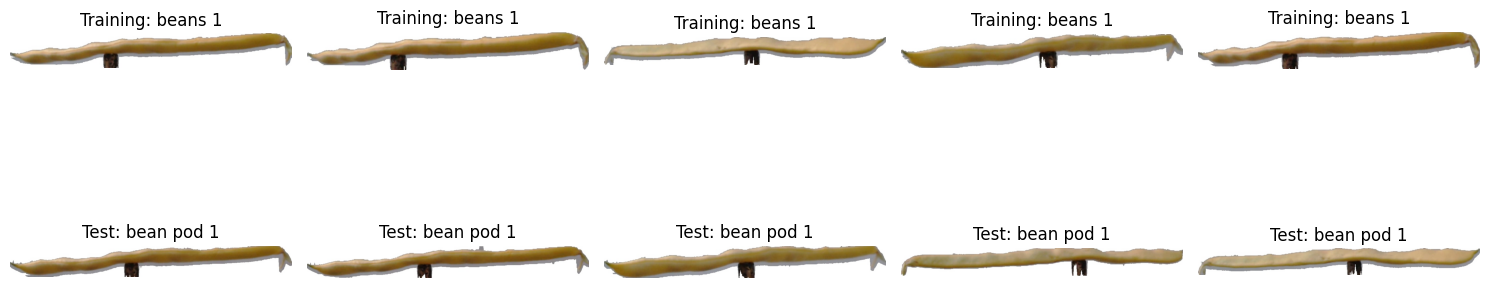

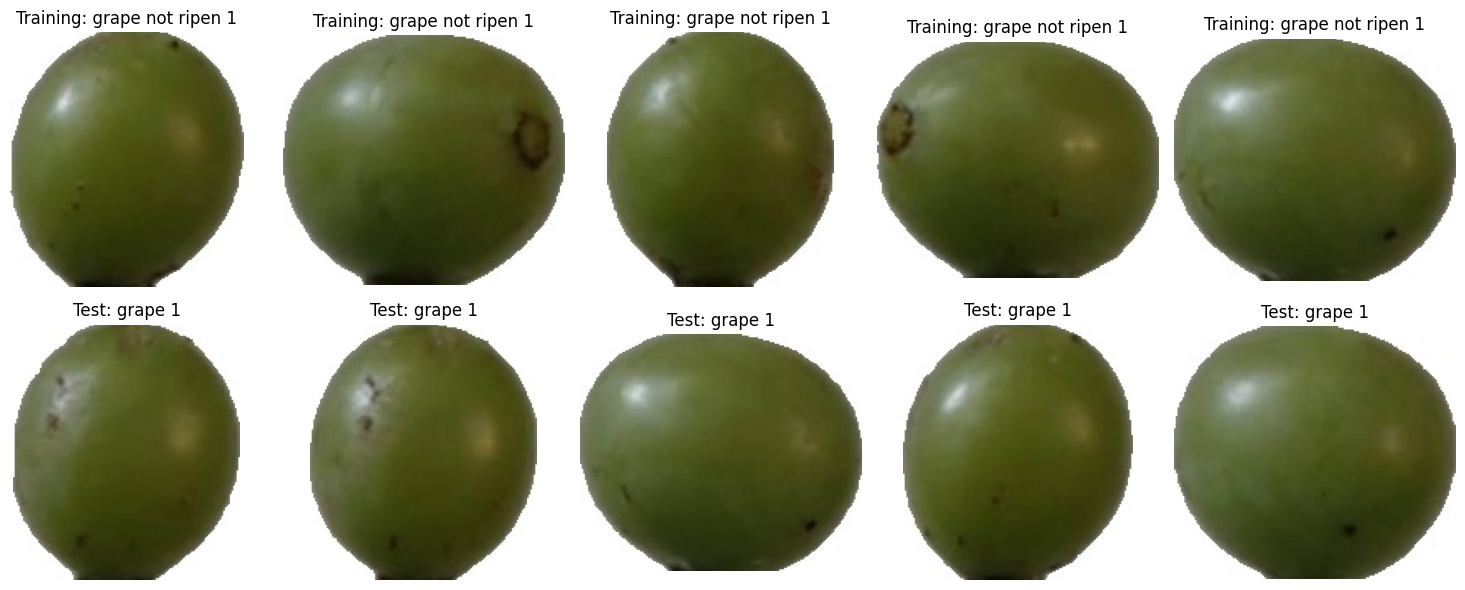

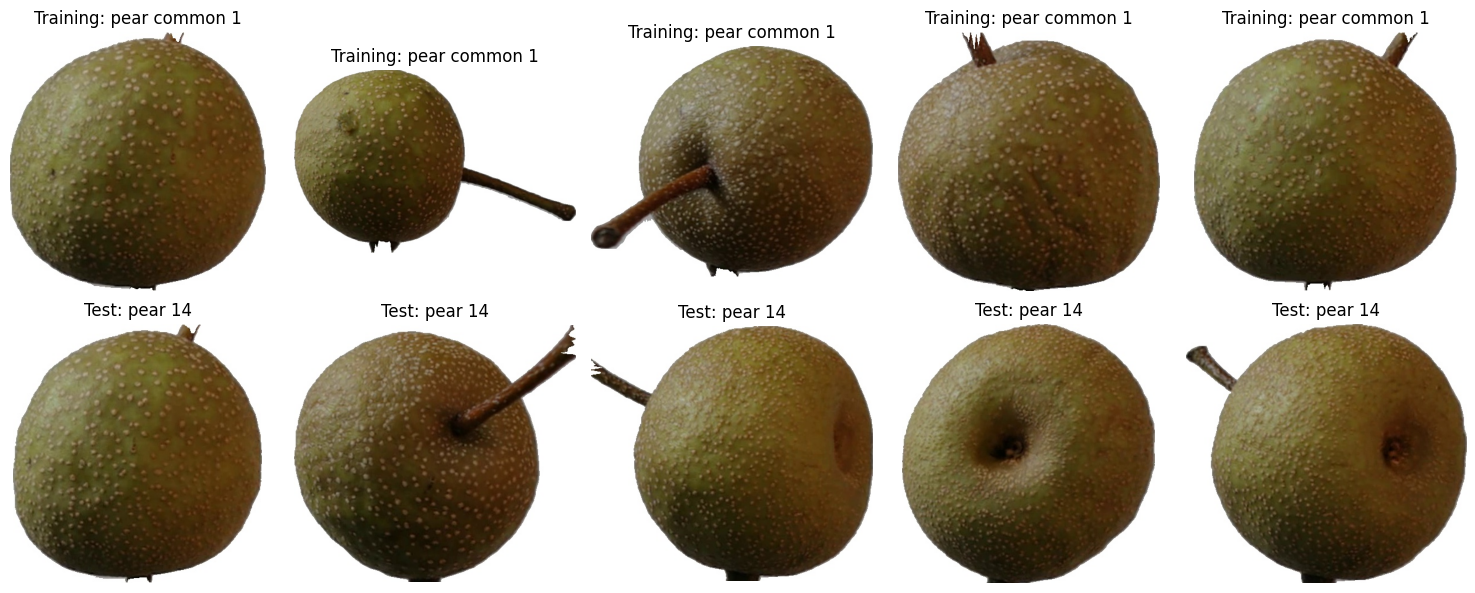

In [30]:
compare_class_images(
    TRAIN / "beans 1",
    TEST / "bean pod 1",
    class_a_name="Training: beans 1",
    class_b_name="Test: bean pod 1",
    n=5
)

compare_class_images(
    TRAIN / "grape not ripen 1",
    TEST / "grape 1",
    class_a_name="Training: grape not ripen 1",
    class_b_name="Test: grape 1",
    n=5
)

compare_class_images(
    TRAIN / "pear common 1",
    TEST / "pear 14",
    class_a_name="Training: pear common 1",
    class_b_name="Test: pear 14",
    n=5
)

**Note:** \
We noticed that there were inconsistences in class names from Train and Test folders. 

To verify whether the mismatched labels represented truly different classes or only naming inconsistencies, sample images from the corresponding folders were displayed side by side. This visual inspection confirmed that the affected labels referred to the same visual categories across splits. Therefore, the classes were not removed. Instead, a label normalization step was applied to map the inconsistent test labels to the corresponding training labels.

In [31]:
label_mapping = {
    "bean pod 1": "beans 1",
    "grape 1": "grape not ripen 1",
    "pear 14": "pear common 1"
}

def normalize_label(label):
    return label_mapping.get(label, label)


# original label for traceability
train_df["original_label"] = train_df["label"]
valid_df["original_label"] = valid_df["label"]
test_df["original_label"] = test_df["label"]

# label normalization
train_df["label"] = train_df["label"].apply(normalize_label)
valid_df["label"] = valid_df["label"].apply(normalize_label)
test_df["label"] = test_df["label"].apply(normalize_label)

In [32]:
train_labels = set(train_df["label"].unique())
valid_labels = set(valid_df["label"].unique())
test_labels = set(test_df["label"].unique())

print("Train labels:", len(train_labels))
print("Validation labels:", len(valid_labels))
print("Test labels:", len(test_labels))

print("Train == Validation:", train_labels == valid_labels)
print("Train == Test:", train_labels == test_labels)

print("\nIn train not validation:")
print(sorted(train_labels - valid_labels))

print("\nIn validation not train:")
print(sorted(valid_labels - train_labels))

print("\nIn train not test:")
print(sorted(train_labels - test_labels))

print("\nIn test not train:")
print(sorted(test_labels - train_labels))

Train labels: 142
Validation labels: 142
Test labels: 142
Train == Validation: True
Train == Test: True

In train not validation:
[]

In validation not train:
[]

In train not test:
[]

In test not train:
[]


Since labels were normalized, all splits should now share the same 142 classes.

In [34]:
if not (train_labels == valid_labels == test_labels):
    raise ValueError(
        "Label mismatch still exists after normalization. "
        "Check the labels printed above before continuing."
    )

class_names = sorted(train_labels)
num_classes = len(class_names)

label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

train_df["label_index"] = train_df["label"].map(label_to_index)
valid_df["label_index"] = valid_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)


In [38]:
print("\nFinal dataset summary")
print("Number of classes:", num_classes)

print("\nTrain classes:", train_df["label"].nunique())
print("Validation classes:", valid_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

print("\nTrain images:", len(train_df))
print("Validation images:", len(valid_df))
print("Test images:", len(test_df))

print("\nApplied label mappings:")
for old_label, new_label in label_mapping.items():
    print(f"{old_label} -> {new_label}")


Final dataset summary
Number of classes: 142

Train classes: 142
Validation classes: 142
Test classes: 142

Train images: 50073
Validation images: 25044
Test images: 24890

Applied label mappings:
bean pod 1 -> beans 1
grape 1 -> grape not ripen 1
pear 14 -> pear common 1


**Observations:**

During dataset inspection, three label inconsistencies were identified between the Training/Validation folders and the Test folder. Manual visual inspection showed that these labels represented the same visual categories but were stored under different folder names. Therefore, the affected classes were not removed. Instead, a label normalization step was applied to map the inconsistent test labels to the corresponding training labels.

This approach preserves all 142 classes while ensuring that the training, validation, and test splits share the same label vocabulary. The original labels were kept in a separate original_label column for traceability, while the normalized labels were used for class indexing and model training.

### Images Decoding

The images are loaded from the file paths stored in the dataframe and converted into datasets. Each image is decoded as an RGB image, resized to 100x100 pixels, and normalized from the original [0, 255] pixel range to [0, 1]. The labels used by the model correspond to the previously created integer label indices.

The training dataset is shuffled to reduce ordering bias during optimization, while the validation and test datasets are kept unshuffled to ensure deterministic evaluation. Finally, batching and prefetching are applied to improve training efficiency.

In [39]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [40]:
def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # decode_image returns a dynamic shape, so we explicitly set it
    image.set_shape([None, None, 3])

    # Resize all images to the input size expected by the custom CNN
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize pixel values from [0, 255] to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

**Note:** 

This function is essential for our first block (**input image**). We decided to resize every image to 100x100 so it lowers our computational cost while maintaining a efficient process. The dataset is very clean, all the images are centered in a white background, so even with a 100x100 size we can preserve a lot of information.

In [43]:
def dataframe_to_dataset(df, shuffle=False):
    filepaths = df["filepath"].values
    labels = df["label_index"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [44]:
train_ds = dataframe_to_dataset(train_df, shuffle=True)
valid_ds = dataframe_to_dataset(valid_df, shuffle=False)
test_ds = dataframe_to_dataset(test_df, shuffle=False)

In [45]:
# Dataset sanity check
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Pixel min:", tf.reduce_min(images).numpy())
    print("Pixel max:", tf.reduce_max(images).numpy())
    print("Labels:", labels[:10].numpy())

Images shape: (32, 100, 100, 3)
Labels shape: (32,)
Pixel min: 0.0
Pixel max: 1.0
Labels: [ 98 107  92  87   1  50  34  56 117   8]


**Observation:**

Now all the images are `100x100` and in a rage of [0,1]. Next we will display a sample batch of images to confirm that the images are being correctly loaded, decoded as RGB images, resized to the expected input shape, and associated with the correct class labels.

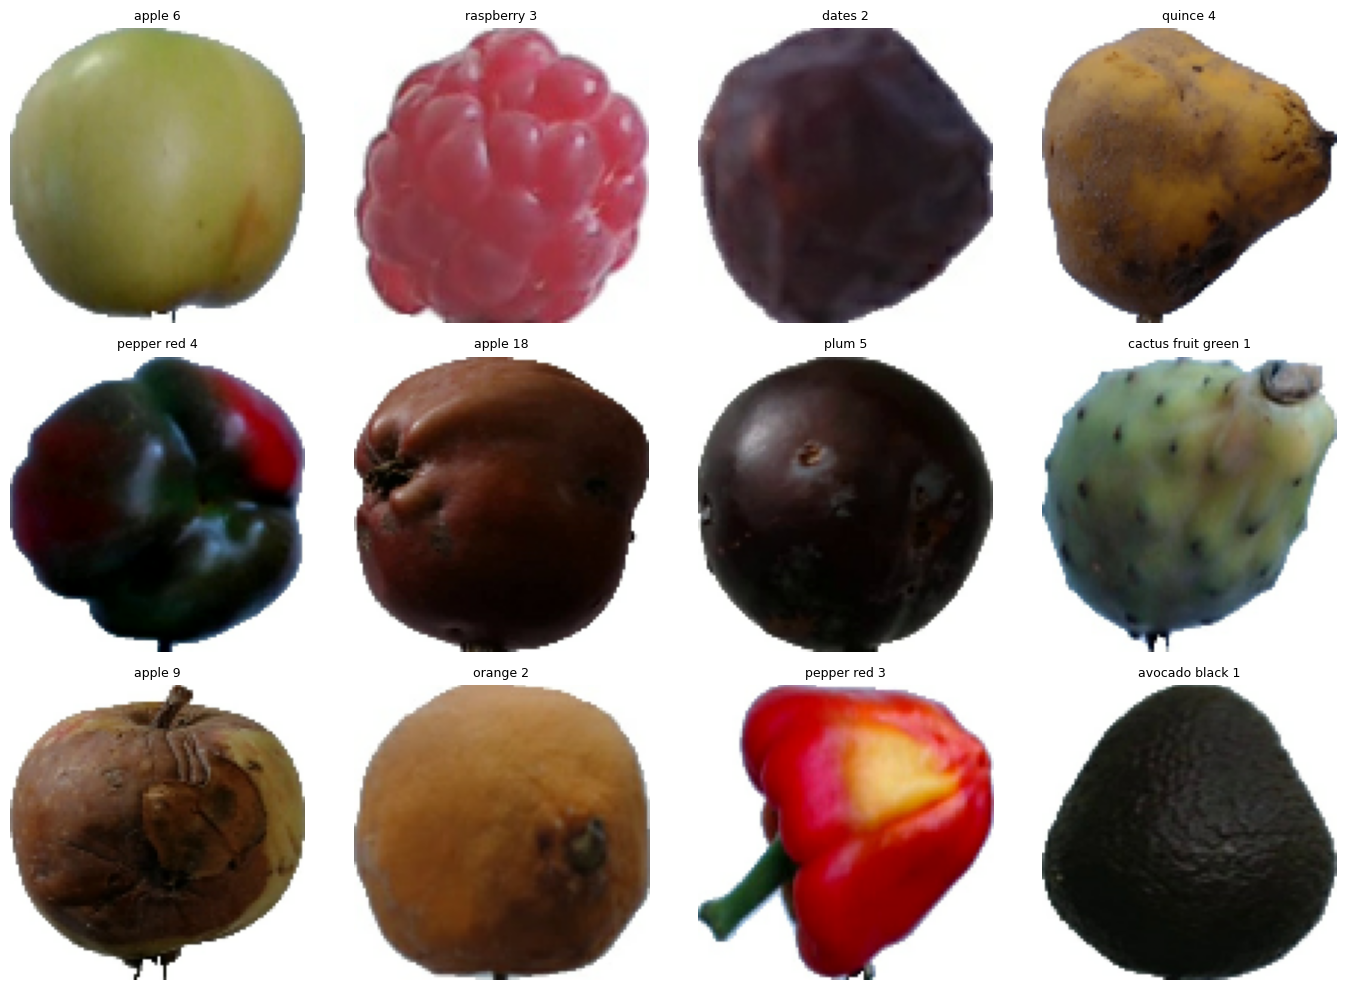

In [46]:
plt.figure(figsize=(14, 10))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(index_to_label[int(labels[i])], fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

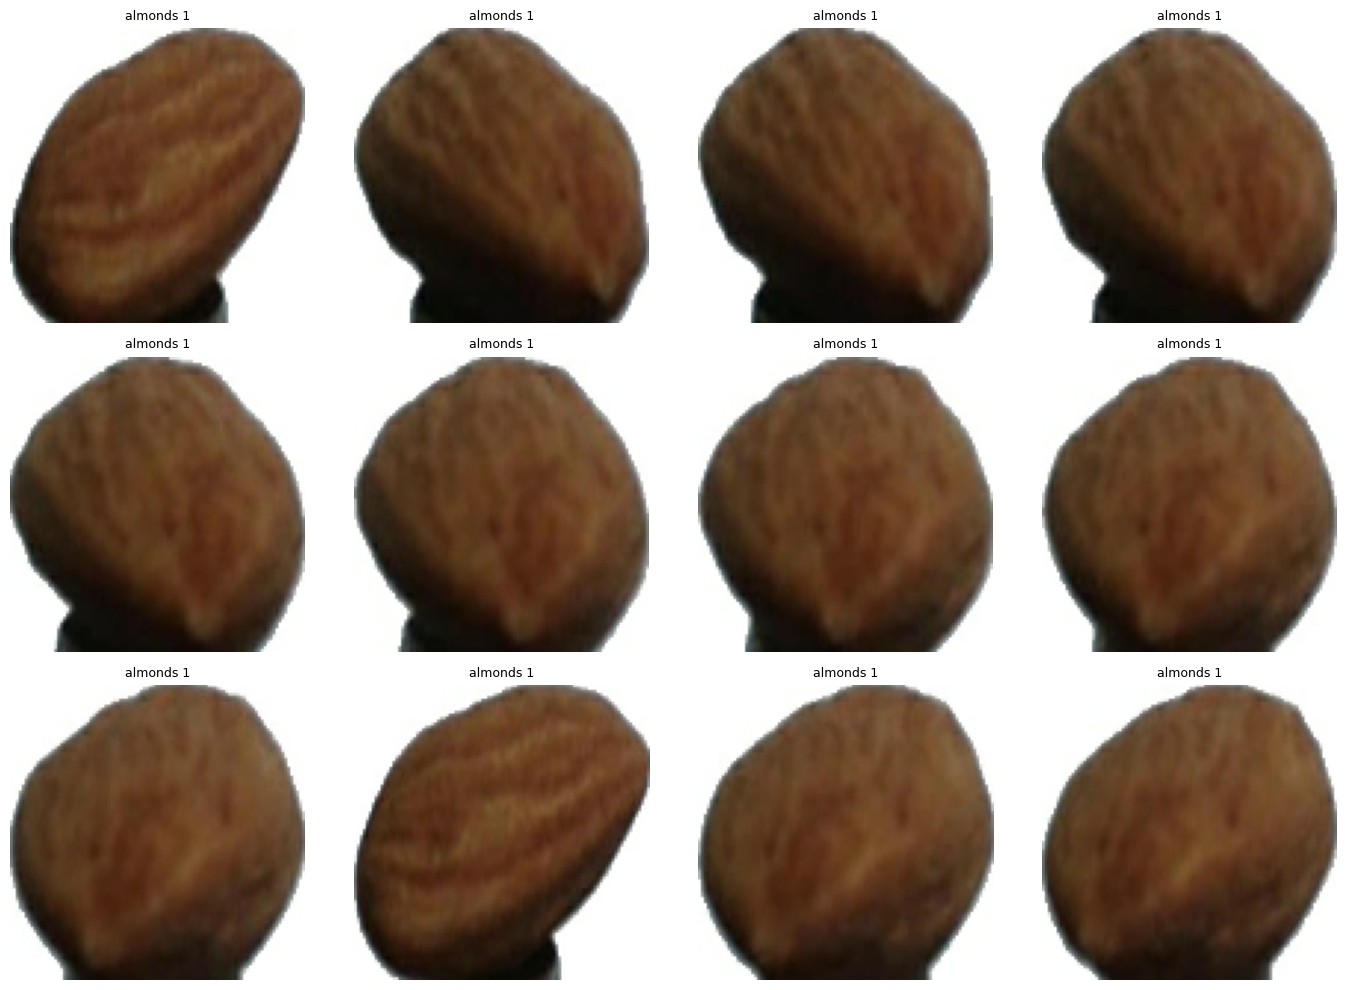

In [47]:
plt.figure(figsize=(14, 10))

for images, labels in valid_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(index_to_label[int(labels[i])], fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

The displayed samples confirm that the preprocessing pipeline preserves the visual content of the images after resizing and that the labels shown above each image match the expected object category.

## Baseline CNN Architecture

Before testing more complex configurations, we will implement a base CNN as a reference model for the classification task. The purpose of this baseline is to establish an initial performance level using a simple architecture, which later we will compare with improved versions involving data augmentation, different architectural choices, regularization strategies, and pretrained networks.

Before implementing we should explain the process. The baseline follows a standard hierarchical CNN structure. It receives RGB images previously resized to 100x100 pixels and processes them through three convolutional blocks. Each block contains a Conv2D layer with a 3x3 kernel, followed by batch normalization and max pooling. The number of filters increases progressively from 32 to 64 and then to 128. We do this so the first layers learn simpler visual patterns and deeper layers can learn more complex representations.

In [71]:
def build_baseline_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),

        # Convolutional block 1
        layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        # Convolutional block 2
        layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        # Convolutional block 3
        layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        # Feature aggregation
        layers.GlobalAveragePooling2D(),

        # Classifier
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        # Output layer
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

The convolutional layers use ReLU activation and same padding.

In [62]:
import base64
from IPython.display import Image, display

def mm_ink(graphbytes):
    """Given a bytes object holding a Mermaid-format graph, return a URL that will generate the image."""
    base64_bytes = base64.b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    return "https://mermaid.ink/img/" + base64_string

def mm_display(graphbytes):
    """Given a bytes object holding a Mermaid-format graph, display it."""
    display(Image(url=mm_ink(graphbytes)))

def mm(graph):
    """Given a string containing a Mermaid-format graph, display it."""
    graphbytes = graph.encode("ascii")
    mm_display(graphbytes)

def mm_link(graph):
    """Given a string containing a Mermaid-format graph, return URL for display."""
    graphbytes = graph.encode("ascii")
    return mm_ink(graphbytes)

In [64]:
mm("""
flowchart TD
    A["Input 100x100x3"] --> B["Conv2D 32 + BatchNorm + MaxPooling"]
    B --> C["Conv2D 64 + BatchNorm + MaxPooling"]
    C --> D["Conv2D 128 + BatchNorm + MaxPooling"]
    D --> E["GlobalAveragePooling"]
    E --> F["Dense 128 + Dropout"]
    F --> G["Dense num_classes + Softmax"]
""")

In [72]:
baseline_model = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

print("Number of classes:", num_classes)
print("Last layer units:", baseline_model.layers[-1].units)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 100, 100, 32)      864       
                                                                 
 batch_normalization_3 (Batc  (None, 100, 100, 32)     128       
 hNormalization)                                                 
                                                                 
 activation (Activation)     (None, 100, 100, 32)      0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 50, 50, 64)        18432     
                                                                 
 batch_normalization_4 (Batc  (None, 50, 50, 64)      

In [73]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [74]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
1565/1565 [==============================] - 280s 179ms/step - loss: 2.1870 - accuracy: 0.4283 - val_loss: 0.6774 - val_accuracy: 0.8507 - lr: 3.0000e-04
Epoch 2/5
1565/1565 [==============================] - 286s 183ms/step - loss: 0.7919 - accuracy: 0.7568 - val_loss: 0.4336 - val_accuracy: 0.8801 - lr: 3.0000e-04
Epoch 3/5
1565/1565 [==============================] - 289s 185ms/step - loss: 0.4741 - accuracy: 0.8505 - val_loss: 0.2801 - val_accuracy: 0.9159 - lr: 3.0000e-04
Epoch 4/5
1565/1565 [==============================] - 290s 185ms/step - loss: 0.3393 - accuracy: 0.8916 - val_loss: 0.1710 - val_accuracy: 0.9545 - lr: 3.0000e-04
Epoch 5/5
1565/1565 [==============================] - 286s 183ms/step - loss: 0.2561 - accuracy: 0.9192 - val_loss: 0.1257 - val_accuracy: 0.9612 - lr: 3.0000e-04


In [75]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

778/778 [==============================] - 48s 61ms/step - loss: 0.1249 - accuracy: 0.9607
Test loss: 0.1249
Test accuracy: 96.07%


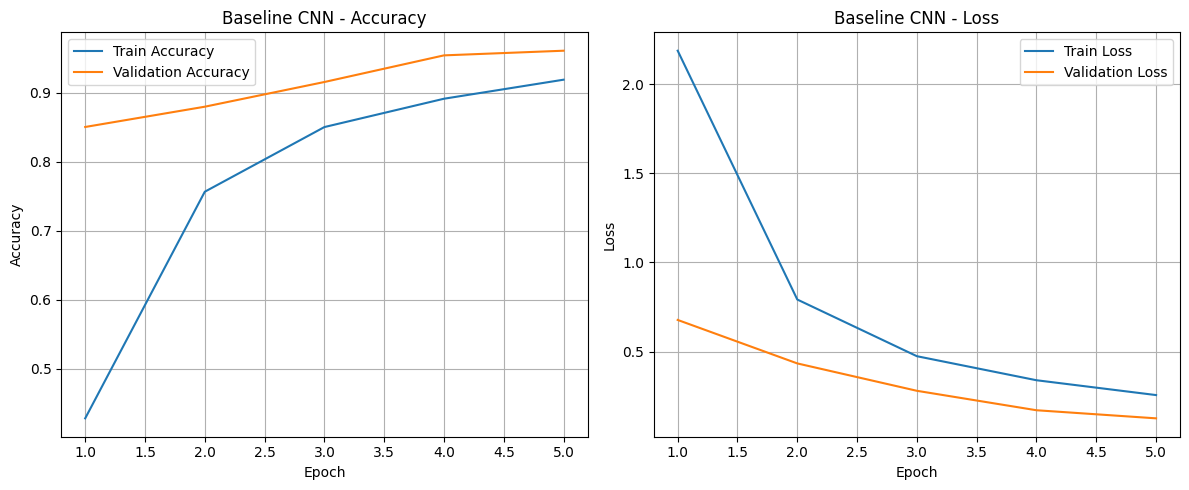

In [76]:
def plot_training_curves(history, title="Training Curves"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_training_curves(history_baseline, "Baseline CNN")

In [77]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = baseline_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

                        precision    recall  f1-score   support

             almonds 1       1.00      1.00      1.00        77
              apple 10       0.98      0.97      0.98       231
              apple 11       1.00      1.00      1.00       142
              apple 12       0.99      0.80      0.88       154
              apple 13       0.98      1.00      0.99       231
              apple 14       1.00      0.98      0.99       154
              apple 17       1.00      0.93      0.97       243
              apple 18       0.94      1.00      0.97       242
              apple 19       0.99      1.00      0.99       241
              apple 20       0.98      1.00      0.99       234
              apple 21       1.00      1.00      1.00       159
              apple 22       0.97      1.00      0.99       231
              apple 23       1.00      1.00      1.00       156
               apple 5       1.00      1.00      1.00       146
               apple 6       0.99      

In [78]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(num_classes),
    zero_division=0
)

class_metrics_df = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})

class_metrics_df = class_metrics_df.sort_values("f1_score")

bad_classes = class_metrics_df[
    (class_metrics_df["precision"] < 0.70) |
    (class_metrics_df["recall"] < 0.70)
].sort_values("f1_score")

bad_classes

,class,precision,recall,f1_score,support
132,tomato 8,0.950980,0.405858,0.568915,239
66,cucumber 4,1.000000,0.500000,0.666667,76
130,tomato 5,1.000000,0.509009,0.674627,222
141,zucchini green 1,0.935484,0.617021,0.743590,47
133,tomato 9,0.627297,1.000000,0.770968,239
16,apple 8,0.954839,0.649123,0.772846,228
59,cherry wax 2,1.000000,0.644737,0.784000,76
128,tomato 1,0.664615,1.000000,0.798521,216
126,strawberry 2,1.000000,0.681818,0.810811,88


In [79]:
results = []

results.append({
    "experiment": "E1 - Baseline CNN",
    "input_size": f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
    "num_classes": num_classes,
    "filters": "32-64-128",
    "kernel_size": "3x3",
    "padding": "same",
    "pooling": "max",
    "augmentation": "no",
    "parameters": baseline_model.count_params(),
    "epochs_trained": len(history_baseline.history["loss"]),
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "best_train_accuracy": max(history_baseline.history["accuracy"]),
    "best_val_accuracy": max(history_baseline.history["val_accuracy"]),
    "best_val_loss": min(history_baseline.history["val_loss"])
})

results_df = pd.DataFrame(results)
results_df

,experiment,input_size,num_classes,filters,kernel_size,padding,pooling,augmentation,parameters,epochs_trained,test_loss,test_accuracy,best_train_accuracy,best_val_accuracy,best_val_loss
0,E1 - Baseline CNN,100x100,142,32-64-128,3x3,same,max,no,128750,5,0.124906,0.960667,0.919218,0.961228,0.125653


#### Baseline CNN architecture observations

The baseline architecture was designed as a simple and interpretable reference model. It follows a hierarchical structure composed of three convolutional blocks. Each block includes a Conv2D layer, batch normalization, and max pooling. The number of filters increases progressively from 32 to 64 and then to 128, allowing the model to learn increasingly complex feature representations. A 3x3 kernel size was used because it is a standard choice for local feature extraction. The convolutional layers use same padding to preserve spatial information before pooling.

Max pooling is applied after each convolutional block to reduce the spatial dimensions of the feature maps. After the convolutional stage, GlobalAveragePooling2D is used instead of flattening the feature maps in a way to limit overfitting. The resulting feature vector is passed to a dense layer with 128 units, followed by dropout regularization.

The output layer contains one neuron per class and uses a softmax activation function. The model is trained with the Adam optimizer and sparse categorical cross-entropy loss, since the target labels are encoded as integer class indices. Accuracy is monitored during training, while precision, recall, F1-score, and per-class metrics are computed after testing to obtain a more detailed evaluation of the model performance.

---
---
---
---
---

| Exp. |     Filters |     Kernel | Stride | Padding | Pooling | Augmentation | Test Acc | Precision | Recall |  F1 |
| ---- | ----------: | ---------: | -----: | ------- | ------- | ------------ | -------: | --------: | -----: | --: |
| E1   |   32-64-128 |        3x3 |      1 | same    | max     | no           |      ... |       ... |    ... | ... |
| E2   |  64-128-256 |        3x3 |      1 | same    | max     | no           |      ... |       ... |    ... | ... |
| E3   |   32-64-128 |        5x5 |      1 | same    | max     | no           |      ... |       ... |    ... | ... |
| E4   |   32-64-128 |        3x3 |      1 | valid   | max     | no           |      ... |       ... |    ... | ... |
| E5   |   32-64-128 |        3x3 |      2 | same    | max     | no           |      ... |       ... |    ... | ... |
| E6   |   32-64-128 |        3x3 |      1 | same    | average | no           |      ... |       ... |    ... | ... |
| E9   |   32-64-128 |        3x3 |      1 | same    | max     | yes          |      ... |       ... |    ... | ... |
| E11  | MobileNetV2 | pretrained |      - | -       | -       | yes          |      ... |       ... |    ... | ... |



| E2          | Mais filtros: 64/128/256     | Avaliar impacto da capacidade       |
| E3          | Kernel size 5x5 vs 3x3       | Avaliar filtros maiores             |
| E4          | Padding `same` vs `valid`    | Avaliar preservação espacial        |
| E5          | Stride 1 vs stride 2         | Avaliar redução espacial            |
| E6          | MaxPooling vs AveragePooling | Comparar pooling methods            |
| E7          | Sem pooling ou menos pooling | Avaliar impacto da redução espacial |
| E8          | Sem data augmentation        | Baseline sem aumento artificial     |
| E9          | Com data augmentation        | Avaliar generalização               |
| E10         | CNN com Dropout/BatchNorm    | Mitigar overfitting                 |
| E11         | MobileNetV2 ou ResNet50      | Transfer learning                   |
